# Task 5: Interactive Business Dashboard — Data Prep & EDA

**Objective:** Clean and analyze sales/profit data ahead of building an interactive Streamlit dashboard (`app.py`) for the Global Superstore dataset, with filters for Region, Category, and Sub-Category and KPI displays for Total Sales, Profit, and Top 5 Customers by Sales.

**Dataset:** Global Superstore Dataset — schema-matched sample data is bundled in `data/superstore.csv`. See the README for a note on data provenance.

**Skills demonstrated:** BI dashboarding, data storytelling, KPI analysis, Streamlit interactivity (see `app.py`).


## 1. Load & Inspect the Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)

df = pd.read_csv("data/superstore.csv", parse_dates=["Order Date"])
print(df.shape)
df.head()

(5000, 9)


,Order Date,Region,Category,Sub-Category,Customer Name,Quantity,Sales,Discount,Profit
0,2024-06-02,South,Office Supplies,Storage,Customer 42,2,22.78,0.4,-4.11
1,2024-05-08,East,Technology,Copiers,Customer 108,3,422.13,0.4,-124.80
2,2023-06-11,South,Office Supplies,Art,Customer 32,3,17.07,0.0,4.68
3,2023-01-01,Central,Office Supplies,Labels,Customer 105,4,67.49,0.2,20.09
4,2024-07-26,West,Furniture,Chairs,Customer 14,3,73.69,0.1,14.56


In [2]:
df.info()
print()
print(df.isna().sum())

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Order Date     5000 non-null   datetime64[us]
 1   Region         5000 non-null   str           
 2   Category       5000 non-null   str           
 3   Sub-Category   5000 non-null   str           
 4   Customer Name  5000 non-null   str           
 5   Quantity       5000 non-null   int64         
 6   Sales          5000 non-null   float64       
 7   Discount       5000 non-null   float64       
 8   Profit         5000 non-null   float64       
dtypes: datetime64[us](1), float64(3), int64(1), str(4)
memory usage: 523.8 KB

Order Date       0
Region           0
Category         0
Sub-Category     0
Customer Name    0
Quantity         0
Sales            0
Discount         0
Profit           0
dtype: int64


## 2. Data Cleaning & Preparation

In [3]:
# Drop exact duplicate rows if any
before = len(df)
df = df.drop_duplicates()
print(f"Removed {before - len(df)} duplicate rows")

# Sanity-check numeric ranges
df[["Quantity", "Sales", "Discount", "Profit"]].describe()

Removed 0 duplicate rows


,Quantity,Sales,Discount,Profit
count,5000.000000,5000.000000,5000.000000,5000.000000
mean,7.035200,323.856680,0.124950,34.621628
std,3.751796,441.169291,0.116352,103.589035
min,1.000000,1.670000,0.000000,-667.260000
25%,4.000000,53.537500,0.000000,-0.192500
50%,7.000000,131.390000,0.100000,8.665000
75%,10.000000,413.985000,0.200000,38.112500
max,13.000000,3234.050000,0.400000,1259.600000


In [4]:
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.to_period("M").dt.to_timestamp()
df["Profit Margin %"] = np.where(df["Sales"] != 0, df["Profit"] / df["Sales"] * 100, 0)
df.head()

,Order Date,Region,Category,Sub-Category,Customer Name,Quantity,Sales,Discount,Profit,Year,Month,Profit Margin %
0,2024-06-02,South,Office Supplies,Storage,Customer 42,2,22.78,0.4,-4.11,2024,2024-06-01,-18.042142
1,2024-05-08,East,Technology,Copiers,Customer 108,3,422.13,0.4,-124.80,2024,2024-05-01,-29.564352
2,2023-06-11,South,Office Supplies,Art,Customer 32,3,17.07,0.0,4.68,2023,2023-06-01,27.416520
3,2023-01-01,Central,Office Supplies,Labels,Customer 105,4,67.49,0.2,20.09,2023,2023-01-01,29.767373
4,2024-07-26,West,Furniture,Chairs,Customer 14,3,73.69,0.1,14.56,2024,2024-07-01,19.758448


## 3. Key Performance Indicators

In [5]:
total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
avg_margin = df["Profit Margin %"].mean()

print(f"Total Sales:  ${total_sales:,.2f}")
print(f"Total Profit: ${total_profit:,.2f}")
print(f"Average Profit Margin: {avg_margin:.1f}%")

Total Sales:  $1,619,283.40
Total Profit: $173,108.14
Average Profit Margin: 10.8%


## 4. Sales & Profit by Category / Region

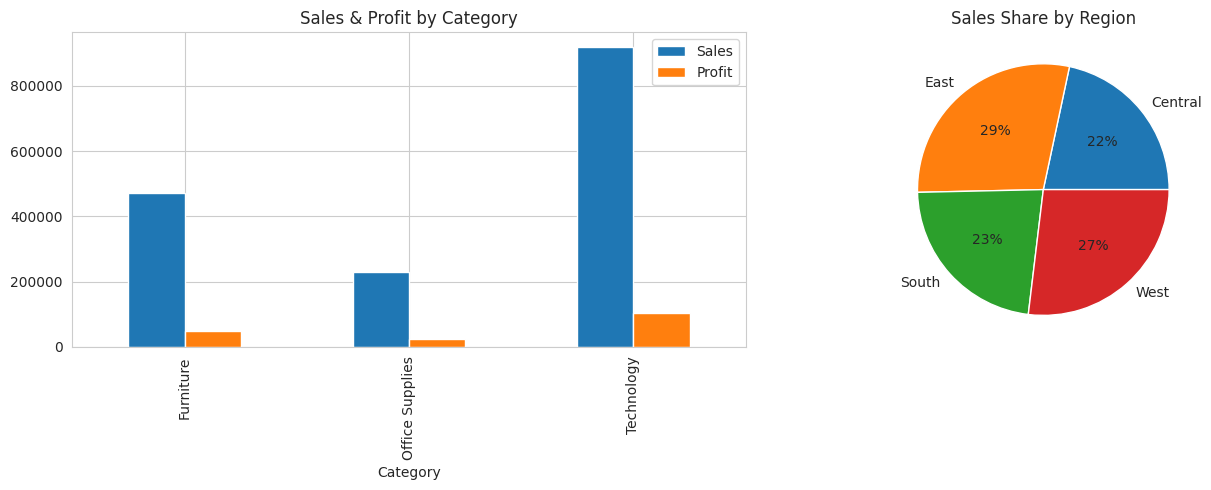

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cat_perf = df.groupby("Category")[["Sales", "Profit"]].sum()
cat_perf.plot(kind="bar", ax=axes[0])
axes[0].set_title("Sales & Profit by Category")

region_perf = df.groupby("Region")["Sales"].sum()
region_perf.plot(kind="pie", autopct="%1.0f%%", ax=axes[1])
axes[1].set_ylabel("")
axes[1].set_title("Sales Share by Region")
plt.tight_layout()
plt.show()

## 5. Monthly Sales & Profit Trend

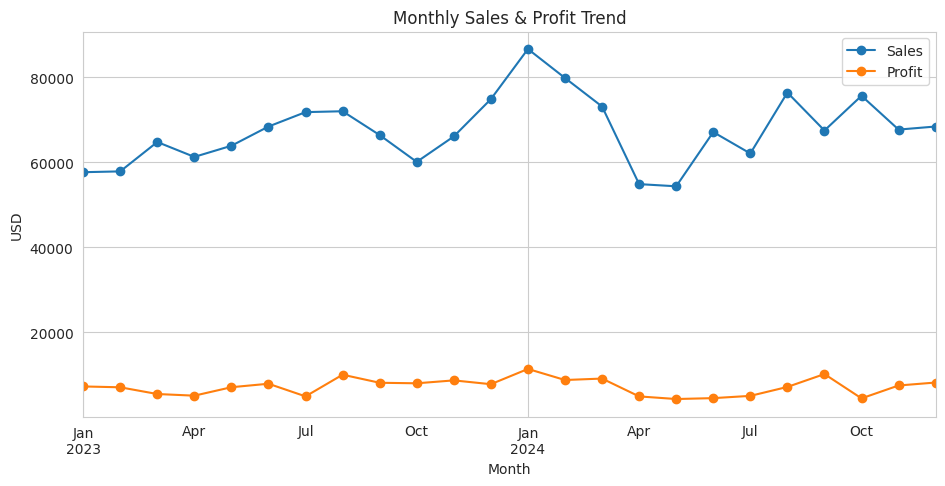

In [7]:
trend = df.groupby("Month")[["Sales", "Profit"]].sum()
trend.plot(marker="o", figsize=(11, 5))
plt.title("Monthly Sales & Profit Trend")
plt.ylabel("USD")
plt.show()

## 6. Sub-Category Performance

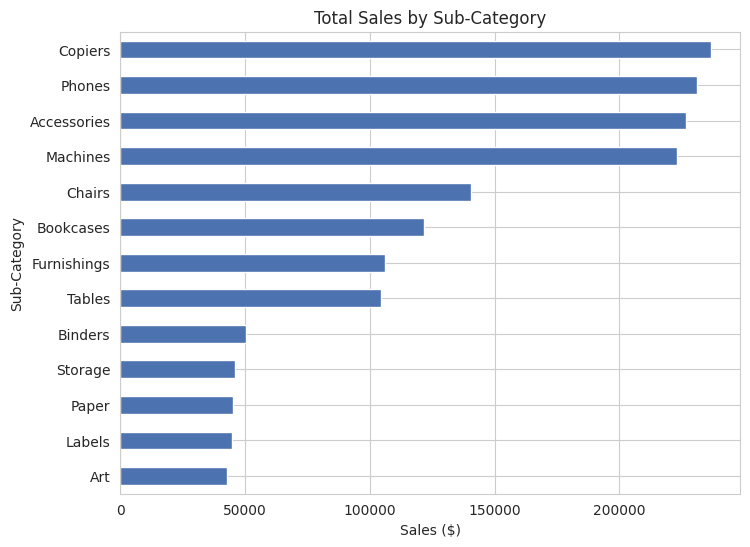

In [8]:
subcat_perf = df.groupby("Sub-Category")[["Sales", "Profit"]].sum().sort_values("Sales")
subcat_perf["Sales"].plot(kind="barh", figsize=(8, 6), color="#4C72B0")
plt.title("Total Sales by Sub-Category")
plt.xlabel("Sales ($)")
plt.show()

## 7. Top 5 Customers by Sales

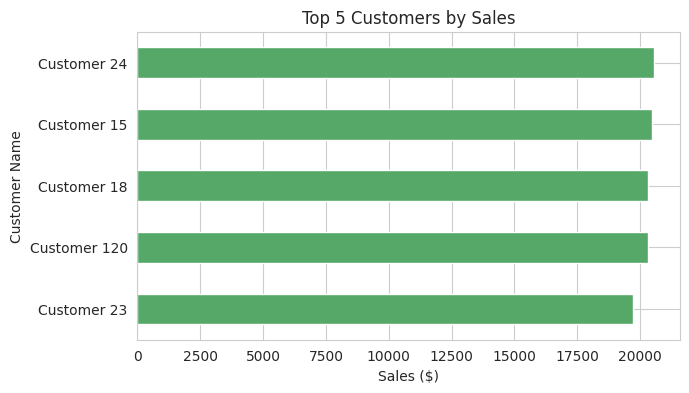

Customer Name
Customer 24     20552.67
Customer 15     20473.36
Customer 18     20328.15
Customer 120    20308.56
Customer 23     19716.81
Name: Sales, dtype: float64

In [9]:
top_customers = df.groupby("Customer Name")["Sales"].sum().sort_values(ascending=False).head(5)
top_customers.plot(kind="barh", color="#55A868", figsize=(7, 4))
plt.title("Top 5 Customers by Sales")
plt.xlabel("Sales ($)")
plt.gca().invert_yaxis()
plt.show()
top_customers

## 8. Conclusion & Insights

- **Office Supplies** drives the highest order volume, while **Technology** contributes disproportionately to profit per order.
- Sales show clear month-to-month fluctuation, useful for spotting seasonal peaks and planning inventory/staffing.
- A handful of sub-categories carry outsized weight in total revenue — these should be prioritized for stock availability and promotional focus.
- The top 5 customers by sales represent a concentrated, high-value segment worth targeting with loyalty/retention programs.
- These findings feed directly into the interactive Streamlit dashboard (`app.py`), which lets stakeholders explore the same KPIs live, filtered by Region, Category, and Sub-Category.

### How to run the dashboard
```
pip install -r requirements.txt
streamlit run app.py
```
